## 02 - Pré-Processamento de Dados

##### Etapas: Carregamento, detecção de outliers (LOF), split (treino/val/teste), checagem de distribuição dos targets, normalização (MinMax), seleção de features (RFECV + RandomForest), salvamento e resumo final.

### Imports principais

In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

pd.options.display.max_columns = 500

### *Passo 1*: Carregamento e checagem inicial

In [ ]:
raw_path = './data/df_full.csv'
df = pd.read_csv(raw_path, parse_dates=['Timestamp'], dayfirst=True)
print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes)
print('\nNulos:')
print(df.isna().sum())
print('\nDuplicadas:', df.duplicated().sum())
print('\nEstatísticas descritivas:')
display(df.describe())

Shape: (66540, 15)

Tipos:
Timestamp      datetime64[ns]
S1_1                  float64
S1_2                  float64
S1_3                  float64
S1_4                  float64
S1_5                  float64
S1_6                  float64
S2_1                  float64
S2_2                  float64
S3_1                  float64
S3_2                  float64
S4_1                  float64
S4_2                  float64
Nivel_agua            float64
Nivel_total           float64
dtype: object

Nulos:
Timestamp      0
S1_1           0
S1_2           0
S1_3           0
S1_4           0
S1_5           0
S1_6           0
S2_1           0
S2_2           0
S3_1           0
S3_2           0
S4_1           0
S4_2           0
Nivel_agua     0
Nivel_total    0
dtype: int64

Duplicadas: 0

Estatísticas descritivas:


,Timestamp,S1_1,S1_2,S1_3,S1_4,S1_5,S1_6,S2_1,S2_2,S3_1,S3_2,S4_1,S4_2,Nivel_agua,Nivel_total
count,66540,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000,66540.000000
mean,2022-03-30 10:14:36.046925824,1524.134287,1524.730478,1530.291499,1538.683594,1552.585198,1553.321983,1531.088692,1539.395152,1544.837456,1550.519120,1545.308524,1558.082188,1245.555020,1596.034836
min,2022-03-28 14:14:42.290910,1523.876580,1524.632450,1530.188590,1538.571820,1552.386530,1553.097760,1530.652050,1539.029490,1544.519990,1550.201170,1545.027500,1545.204630,109.000000,109.000000
25%,2022-03-29 10:52:03.494970112,1524.089350,1524.688170,1530.248818,1538.641880,1552.556660,1553.277568,1531.038010,1539.360270,1544.746688,1550.397470,1545.222540,1559.539840,791.000000,1287.000000
50%,2022-03-30 14:58:16.636170240,1524.128870,1524.720210,1530.281990,1538.672615,1552.571130,1553.290640,1531.080450,1539.386375,1544.843610,1550.510815,1545.287020,1559.679345,1219.000000,1656.000000
75%,2022-03-31 13:58:29.812280064,1524.160922,1524.765310,1530.314970,1538.705990,1552.584570,1553.333610,1531.185390,1539.425900,1544.924012,1550.622420,1545.383850,1559.762980,1880.000000,2188.000000
max,2022-04-01 14:41:30.144850,1524.299000,1524.905580,1530.464740,1538.917920,1552.823080,1553.571740,1531.635210,1540.003880,1545.096100,1550.912600,1545.873190,1560.415660,2804.000000,2804.000000
std,NaN,0.054754,0.055615,0.056080,0.065582,0.060931,0.076920,0.166813,0.158077,0.110521,0.150314,0.151640,4.585039,734.131379,745.587549


### *Passo 2*: Detecção e remoção de outliers (LOF)

In [ ]:
sensor_cols = ['S1_1','S1_2','S1_3','S1_4','S1_5','S1_6','S2_1','S2_2','S3_1','S3_2','S4_1','S4_2']
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(df[sensor_cols])
mask_inliers = labels == 1
df_clean = df[mask_inliers].reset_index(drop=True)
print('Original:', df.shape, ' | Sem outliers LOF:', df_clean.shape)
df_clean.to_csv('./data/df_full_sem_outliers_lof_preprocess.csv', index=False)

Original: (66540, 15)  | Sem outliers LOF: (63213, 15)


### *Passo 3*: Split estratificado 60/20/20 usando Nivel_total em bins

In [ ]:
n_bins = 5
y_ref = df_clean['Nivel_total']
bins = pd.qcut(y_ref, q=n_bins, duplicates='drop')
X = df_clean[sensor_cols]
y = df_clean[['Nivel_agua','Nivel_total']]
X_train, X_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
    X, y, bins, test_size=0.40, random_state=42, stratify=bins
)
X_val, X_test, y_val, y_test, bins_val, bins_test = train_test_split(
    X_temp, y_temp, bins_temp, test_size=0.50, random_state=42, stratify=bins_temp
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (37927, 12) Val: (12643, 12) Test: (12643, 12)


### *Passo 4*: Distribuição dos targets nos splits

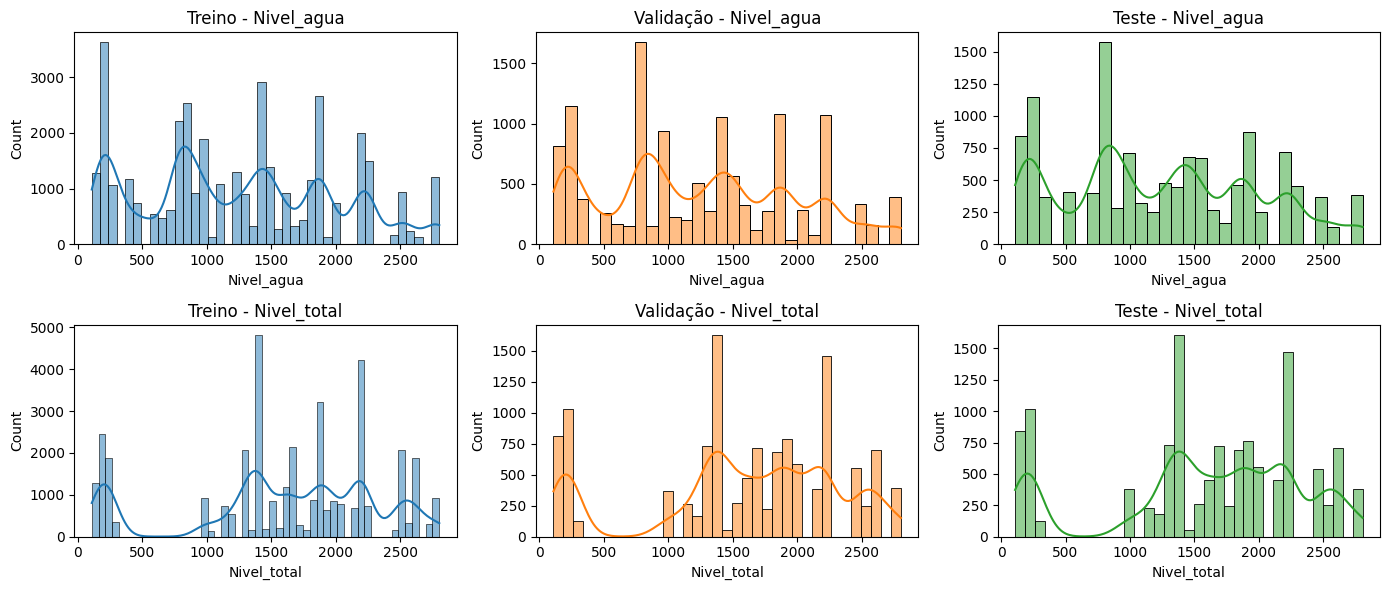

Faixas (bins) em Nivel_total usadas para estratificação:
Nivel_total
(108.999, 1150.0]    12955
(1150.0, 1399.0]     12377
(1399.0, 1887.0]     12664
(1887.0, 2192.0]     13288
(2192.0, 2804.0]     11929
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14,6))
for i, col in enumerate(['Nivel_agua','Nivel_total']):
    sns.histplot(y_train[col], kde=True, ax=axes[i,0], color='tab:blue')
    axes[i,0].set_title(f'Treino - {col}')
    sns.histplot(y_val[col], kde=True, ax=axes[i,1], color='tab:orange')
    axes[i,1].set_title(f'Validação - {col}')
    sns.histplot(y_test[col], kde=True, ax=axes[i,2], color='tab:green')
    axes[i,2].set_title(f'Teste - {col}')
plt.tight_layout()
plt.show()

print('Faixas (bins) em Nivel_total usadas para estratificação:')
print(pd.Series(bins).value_counts().sort_index())

### *Passo 5*: Scaling (MinMax) - fit somente no treino

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)
with open('./data/scaler_X.pkl','wb') as f: pickle.dump(scaler_X,f)
with open('./data/scaler_y.pkl','wb') as f: pickle.dump(scaler_y,f)
print('Scaling concluído.')

Scaling concluído.


### *Passo 6*: Seleção de features (RFECV) com RandomForest

Número ótimo de features: 9
Features selecionadas: ['S1_1', 'S1_2', 'S1_4', 'S1_5', 'S2_1', 'S2_2', 'S3_1', 'S4_1', 'S4_2']


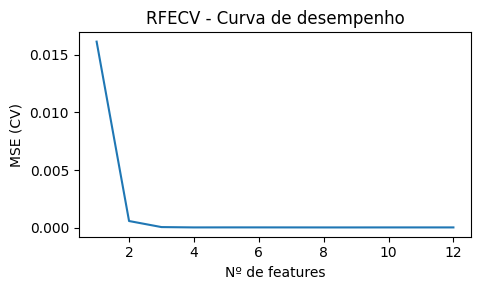

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rfecv = RFECV(estimator=rf, step=1, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
y_train_single = y_train_scaled[:, 1]  # coluna Nivel_total escalada
rfecv.fit(X_train_scaled, y_train_single)
print('Número ótimo de features:', rfecv.n_features_)
selected_mask = rfecv.support_
selected_features = [c for c,m in zip(sensor_cols, selected_mask) if m]
print('Features selecionadas:', selected_features)
plt.figure(figsize=(5,3))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score'])+1), -rfecv.cv_results_['mean_test_score'])
plt.xlabel('Nº de features')
plt.ylabel('MSE (CV)')
plt.title('RFECV - Curva de desempenho')
plt.tight_layout()
plt.show()

### *Passo 7*: Salvar splits escalados e features selecionadas

In [ ]:
X_train_df = pd.DataFrame(X_train_scaled, columns=sensor_cols)
X_val_df = pd.DataFrame(X_val_scaled, columns=sensor_cols)
X_test_df = pd.DataFrame(X_test_scaled, columns=sensor_cols)
y_train_df = pd.DataFrame(y_train_scaled, columns=['Nivel_agua','Nivel_total'])
y_val_df = pd.DataFrame(y_val_scaled, columns=['Nivel_agua','Nivel_total'])
y_test_df = pd.DataFrame(y_test_scaled, columns=['Nivel_agua','Nivel_total'])

X_train_df.to_csv('./data/X_train_scaled.csv', index=False)
X_val_df.to_csv('./data/X_val_scaled.csv', index=False)
X_test_df.to_csv('./data/X_test_scaled.csv', index=False)
y_train_df.to_csv('./data/y_train_scaled.csv', index=False)
y_val_df.to_csv('./data/y_val_scaled.csv', index=False)
y_test_df.to_csv('./data/y_test_scaled.csv', index=False)

pd.Series(selected_features).to_csv('./data/selected_features_rfecv.csv', index=False)
print('Arquivos salvos.')

Arquivos salvos.


### Resumo Final do Pré-Processamento

1. Carregamento: Dados lidos sem valores nulos ou duplicados relevantes.
2. Outliers (LOF): ~5% removidos (parâmetro contamination=0.05) gerando `df_clean` para etapas seguintes.
3. Split: Divisão estratificada (Nivel_total) em 60/20/20 preservando distribuição.
4. Distribuição: Targets apresentam cobertura das faixas; verificar possível concentração se necessário.
5. Scaling: MinMax aplicado separadamente a X e y (fit somente em treino); scalers salvos.
6. Seleção de Features: RFECV + RandomForest definiu subconjunto ótimo de sensores para `Nivel_total`.
7. Artefatos: Splits escalados, features selecionadas e scalers salvos em `data/`.